In [1]:
from numba import jit, cuda
from utils import *
st = time.time()

In [2]:
path="../../DATA/registration_test/FB_100030____FB,2817673489/study_0c1e55cc/"
path_subfolder1=path+"MR7_bb3b1a0b"#"MR3_33a7c6a2"#"MR4_c61744e9"#"MR3_33a7c6a2"
path_subfolder2=path+"MR5_2e0c276a"
path_subfolder3=path+"MR3_33a7c6a2"

In [3]:
# read 2 series (sagittal / coronal / axial)
sag_image=serie_reader(path_subfolder1)
cor_image = serie_reader(path_subfolder2)
ax_image= serie_reader(path_subfolder3)

vType= sag_image.GetPixelIDTypeAsString()

In [4]:
# get spacing of each volume (dependent of orientation)
spacing_sag=get_spacing(sag_image)
spacing_cor=get_spacing(cor_image)
spacing_ax=get_spacing(ax_image)

print(spacing_sag, spacing_cor, spacing_ax)

[[0.4375    0.        0.       ]
 [0.        0.4375    0.       ]
 [0.        0.        3.3000002]] [[0.4375 0.     0.    ]
 [0.     0.4375 0.    ]
 [0.     0.     3.3   ]] [[0.4375 0.     0.    ]
 [0.     0.4375 0.    ]
 [0.     0.     3.6   ]]


In [5]:
# get direction cosin matrix of each volume (dependent of orientation)
dir_sag = get_direction(sag_image)
dir_cor = get_direction(cor_image)
dir_ax = get_direction(ax_image)

In [6]:
A_sag=np.dot(dir_sag, spacing_sag)
A_cor=np.dot(dir_cor, spacing_cor)
A_ax=np.dot(dir_ax, spacing_ax)

In [7]:
origin_sag= np.array(sag_image.GetOrigin())
origin_cor= np.array(cor_image.GetOrigin())
origin_ax = np.array(ax_image.GetOrigin())
print(origin_cor, origin_ax, origin_sag)

[  20.95518583 -102.72428033   48.84761293] [  29.43934254 -105.36338197  -81.23900868] [ 117.90852282 -103.56080763   53.28039366]


In [8]:
m_sag=sitk.GetArrayFromImage(sag_image)
m_cor=sitk.GetArrayFromImage(cor_image)
m_ax=sitk.GetArrayFromImage(ax_image)

print(sag_image.GetSize(), m_sag.shape)

(320, 320, 32) (32, 320, 320)


In [9]:
print("sag \n")
xspa_sag=calcul_physicsCoo(origin_sag, A_sag, m_sag)
print("cor \n")
xspa_cor=calcul_physicsCoo(origin_cor, A_cor, m_cor)
print("ax \n")
xspa_ax=calcul_physicsCoo(origin_ax, A_ax, m_ax)

sag 



100%|██████████| 32/32 [00:20<00:00,  1.57it/s]


cor 



100%|██████████| 34/34 [00:21<00:00,  1.57it/s]


ax 



100%|██████████| 31/31 [00:18<00:00,  1.64it/s]


In [10]:
sag_d= pd.DataFrame(xspa_sag, columns=('x', 'y', 'z', 'i'))
cor_d= pd.DataFrame(xspa_cor, columns=('x', 'y', 'z', 'i'))
ax_d= pd.DataFrame(xspa_ax, columns=('x', 'y', 'z', 'i'))

datas = [sag_d, cor_d, ax_d]
datas_combined = pd.concat(datas)
print(datas_combined.head())

#print(datas_combined.sort_values(by=['x', 'y', 'z']).head())
newres=np.min(np.asarray([sag_image.GetSpacing(), cor_image.GetSpacing(), ax_image.GetSpacing()]))
print(newres)

            x           y          z    i
0  117.908523 -103.560808  53.280394  0.0
1  117.969399 -103.127564  53.280394  0.0
2  118.030276 -102.694320  53.280394  0.0
3  118.091152 -102.261076  53.280394  0.0
4  118.152028 -101.827832  53.280394  0.0
0.4375


In [12]:
xyzi= datas_combined.sort_values(by=['x', 'y', 'z']).to_numpy()
print(xyzi)

print(xyzi[:30,0])
#xyz_c= xyzi[['x', 'y', 'z']].to_numpy()
#intensities=xyzi['i'].to_numpy()
#print(xyz_c.shape)

[[-10.49432384  24.40390617  31.48829063  30.        ]
 [-10.39016692  23.97928469  31.47234729  30.        ]
 [-10.28601     23.55466322  31.45640396  30.        ]
 ...
 [164.50330383 -71.71428472 -71.04481201   0.        ]
 [164.60746075 -72.1389062  -71.06075534   0.        ]
 [164.71161767 -72.56352767 -71.07669867   0.        ]]
[-10.49432384 -10.39016692 -10.28601    -10.27073688 -10.18185308
 -10.16657996 -10.07769616 -10.07027282 -10.06242304 -10.04714992
  -9.97353924  -9.9661159   -9.95826612  -9.942993    -9.86938232
  -9.86195898  -9.8541092   -9.84668586  -9.83883608  -9.82356296
  -9.7652254   -9.75780206  -9.74995228  -9.74252894  -9.73467916
  -9.71940604  -9.66106848  -9.65364514  -9.6462218   -9.64579536]


In [12]:
minminmin=np.array([datas_combined['x'].min(), datas_combined['y'].min(), datas_combined['z'].min()]) 
maxmaxmax=np.array([datas_combined['x'].max(), datas_combined['y'].max(), datas_combined['z'].max()])
print(minminmin.dtype, maxmaxmax)
new_origin, new_spacing, dir_new = define_param(newres, minminmin, maxmaxmax)

sizeX=ceil((datas_combined['x'].max()-datas_combined['x'].min())/newres)
sizeY=ceil((datas_combined['y'].max()-datas_combined['y'].min())/newres)
sizeZ=ceil((datas_combined['z'].max()-datas_combined['z'].min())/newres)
print(newres, new_origin, new_spacing, dir_new, sizeX, sizeY, sizeZ)

float64 [164.71161767  62.8907225   56.71900472]
0.4375 [-10.49432384  62.8907225  -90.56740399] [[0.4375 0.     0.    ]
 [0.     0.4375 0.    ]
 [0.     0.     0.4375]] [[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]] 401 398 337


In [13]:
s=160 #128 crop

I=np.arange(int((sizeX/2)-s),int((sizeX/2)+s))
J=np.arange(int((sizeY/2)-s),int((sizeY/2)+s))
K=np.arange(int((sizeZ/2)-s),int((sizeZ/2)+s))
#np.dot(A_new, np.array([i,j,k]))
#print(I)
A_new=np.dot(dir_new, new_spacing)

ii, jj, kk = np.meshgrid(I,J,K, indexing='ij')
I012 = np.zeros((ii.shape[0], jj.shape[1], kk.shape[2], 3))
I012[:,:,:,0] = ii
I012[:,:,:,1] = jj
I012[:,:,:,2] = kk
print(ii.shape, jj.shape, kk.shape)
print(sizeX, sizeY, sizeZ)

XYZ=new_origin + np.einsum('ijkl,lm->ijkm', I012, A_new)
print(XYZ.shape)


(320, 320, 320) (320, 320, 320) (320, 320, 320)
401 398 337
(320, 320, 320, 3)


In [14]:
d=newres*2
sd=10
new_vol = np.zeros((XYZ.shape[0],XYZ.shape[1], XYZ.shape[2]))
new_vol[:] =np.nan

for i in tqdm(range(int((XYZ.shape[0]/2)-sd),int((XYZ.shape[0]/2)+sd))):#0, XYZ.shape[0]
    x_in=datas_combined[
    for j in range(int((XYZ.shape[1]/2)-sd),int((XYZ.shape[1]/2)+sd)):
        for k in range(int((XYZ.shape[2]/2)-sd),int((XYZ.shape[2]/2)+sd)):
            xyz=XYZ[i,j,k]
            
            #print(xyz, xyz-d, xyz+d)
            neigb= xyzi[np.where((xyzi[:,0]<=xyz[0]+d) & (xyzi[:,1]<=xyz[1]+d) & (xyzi[:,2]<=xyz[2]+d)&
                        (xyzi[:,0]>=xyz[0]-d) & (xyzi[:,1]>=xyz[1]-d) & (xyzi[:,2]>=xyz[2]-d))]
            new_vol[i,j,k]=np.nanmean(neigb[:,3])
            #print(neigb)
            

100%|██████████| 20/20 [18:18<00:00, 54.90s/it]


In [16]:
print(new_vol.shape)
print(np.sum(np.isnan(new_vol)))
print(np.sum(~np.isnan(new_vol)))
combined_vol=np.nan_to_num(new_vol, nan=0).astype(np.int32)

(320, 320, 320)
32760598
7402


In [24]:
d=newres
vol3=XYZ.reshape((-1, 3))
print(vol3.shape)
sca_x=xyzi[:, 0]
sca_y=xyzi[:, 1]
sca_z=xyzi[:, 2]
sca_i=xyzi[:, 3]
print(sca_i.shape)
#condition = sca_i[np.where((sca_x >= vol3[:, 0] - d) & (sca_x <= vol3[:, 0] + d) &(sca_y >= vol3[:, 1] - d) & (sca_y <= vol3[:, 1] + d) &(sca_z >= vol3[:, 2] - d) & (sca_z <= vol3[:, 2] + d))]
#condition = sca_i[np.where((sca_x >= vol3[:][0]-d) & (sca_x <=vol3[:][0]+d ) & (sca_y >= vol3[:][1]-d) & (sca_y <= vol3[:][1]+d) & (sca_z >= vol3[:][2]-d) & (sca_z <= vol3[:][2]+d))] #for v in tqdm(range(0,vol3.shape[0]))]
print(condition.shape)

(32768000, 3)
(9932800,)


ValueError: operands could not be broadcast together with shapes (9932800,) (32768000,) 

In [18]:
d = newres
new_vol = np.zeros(XYZ.shape)
new_vol[:] = np.nan

# Create broadcasted indices for XYZ
i, j, k = np.ogrid[:XYZ.shape[0], :XYZ.shape[1], :XYZ.shape[2]]

# Create the conditions using broadcasting
condition_x = (xyzi[:, 0] <= XYZ[i, j, k, 0] + d) & (xyzi[:, 0] >= XYZ[i, j, k, 0] - d)
condition_y = (xyzi[:, 1] <= XYZ[i, j, k, 1] + d) & (xyzi[:, 1] >= XYZ[i, j, k, 1] - d)
condition_z = (xyzi[:, 2] <= XYZ[i, j, k, 2] + d) & (xyzi[:, 2] >= XYZ[i, j, k, 2] - d)

# Combine the conditions
condition_all = condition_x & condition_y & condition_z

# Perform the nanmean operation using the condition to select relevant elements
new_vol[i, j, k] = np.nanmean(xyzi[condition_all, 3], axis=1)

ValueError: operands could not be broadcast together with shapes (9932800,) (320,320,320) 

In [25]:
d=newres
new_vol = np.zeros((XYZ.shape))
new_vol[:] =np.nan

neigb= xyzi[np.where((xyzi[:,0]<=xyz[..., 0]+d) & (xyzi[:,1]<=xyz[..., 1]+d) & (xyzi[:,2]<=xyz[..., 2]+d)&
                     (xyzi[:,0]>=xyz[..., 0]-d) & (xyzi[:,1]>=xyz[..., 1]-d) & (xyzi[:,2]>=xyz[..., 2]-d))]

#new_vol[:,:,:]=np.nanmean(neigb[:,3])
print( neigb.shape)

(0, 4)


In [ ]:
print(sag_d.x.min(), sag_d.y.min(), sag_d.z.min(), origin_sag)
print(m_sag.shape[0])

In [15]:
print(np.sum(np.isnan(combined_vol)))
print(np.sum(~np.isnan(combined_vol)))
combined_vol=np.nan_to_num(combined_vol, nan=0).astype(np.int32)

7173268
25594732


In [17]:
plt_vol= k3d.volume(combined_vol.astype(np.float32), alpha_coef=75,color_map=matplotlib_color_maps.Turbo)
plot = k3d.plot()
plot += plt_vol

plot.display()

Output()

(320, 320, 320)



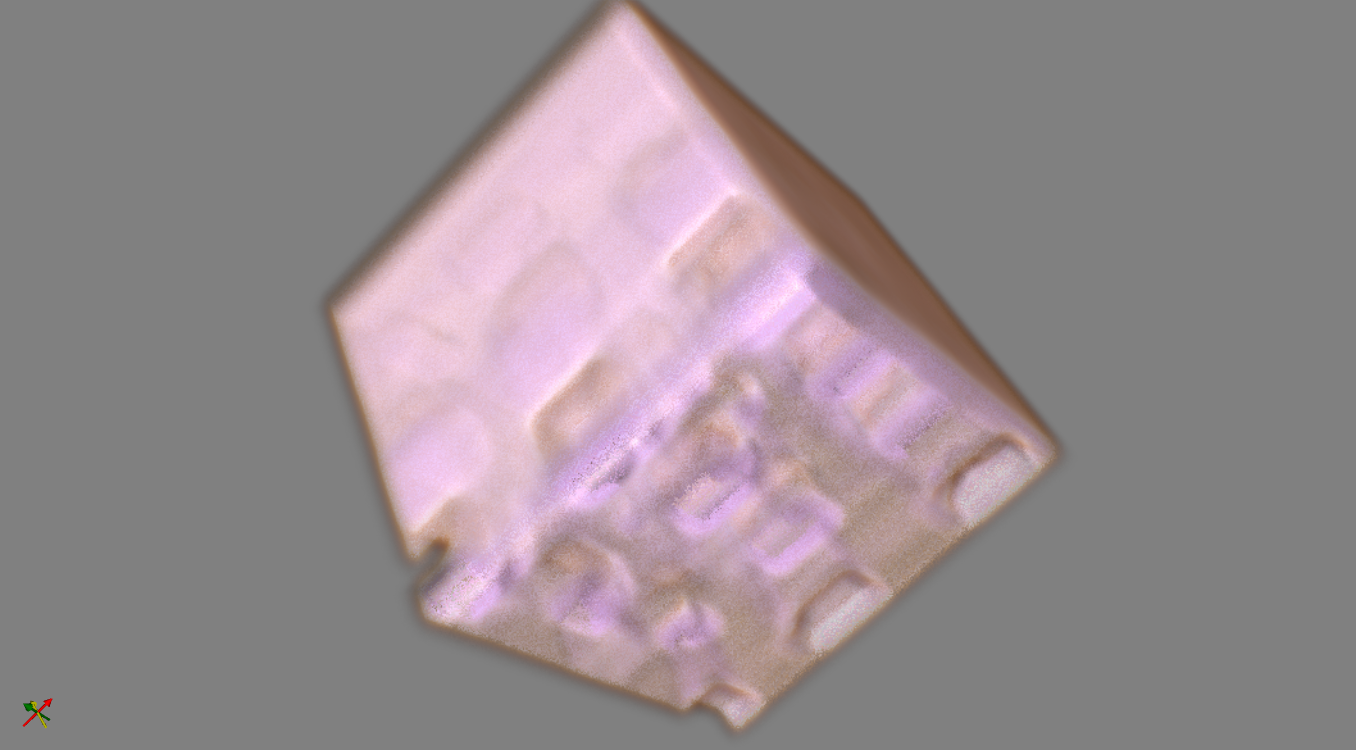
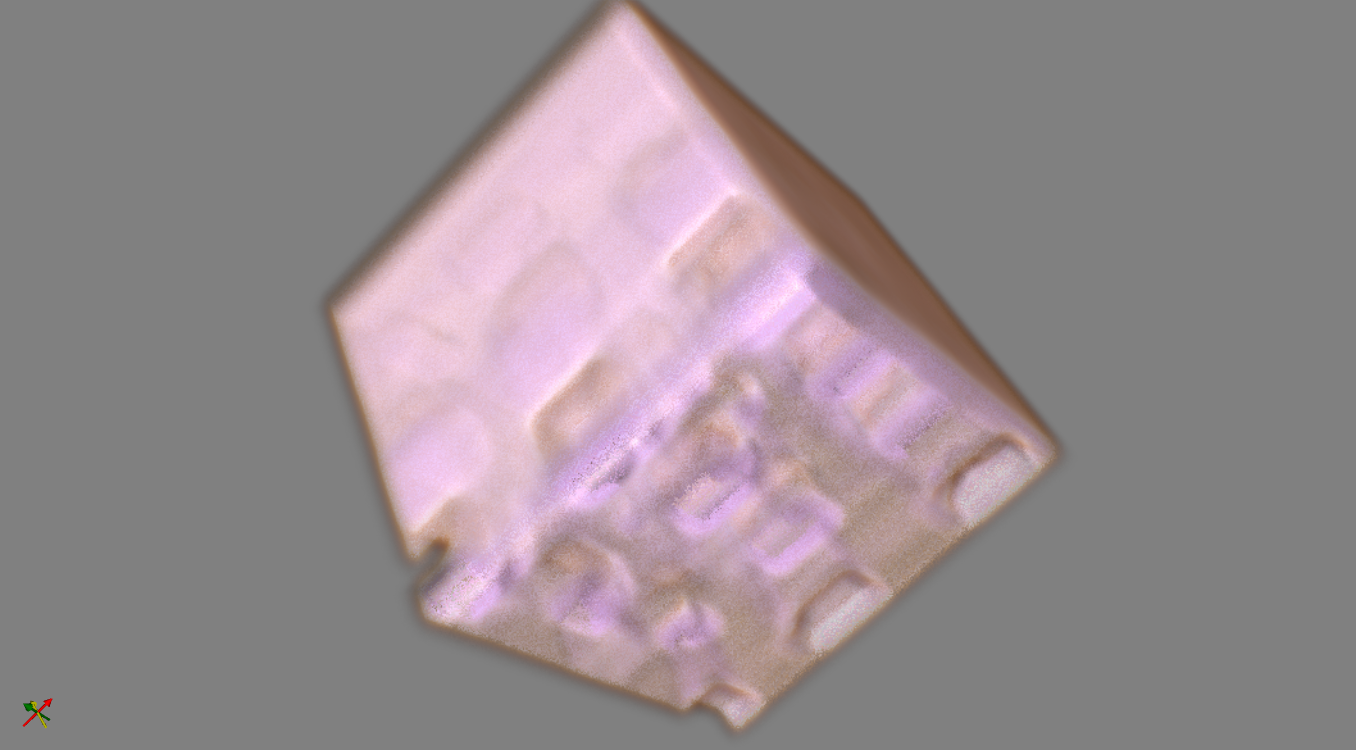

<IPython.core.display.Javascript object>

In [18]:
itk_view = itk_view_from_simpleitk(combined_vol.astype(np.float32), (newres, newres, newres), dir_new, new_origin)
#itk_view = itk_view_from_simpleitk(m_cor, cor_image.GetSpacing() , dir_cor, origin_cor)
itkwidgets.view(itk_view)

In [19]:
# Converting back to SimpleITK (assumes we didn't move the image in space as we copy the information from the original)
filename='VOL_TEST.nii.gz'
nv=combined_vol.astype(np.uint16)
result_image = sitk.Image(list(nv.shape), sitk.sitkUInt16)
result_image = sitk.GetImageFromArray(nv)
result_image.SetSpacing((newres, newres, newres))
result_image.SetOrigin(new_origin)
result_image.SetDirection(tuple(dir_new.flatten()))
    
# write the image
sitk.WriteImage(result_image, filename)

In [19]:
et = time.time()
# get the execution time
elapsed_time = (et - st)/60
print('Execution time:', elapsed_time, 'minutes')

Execution time: 1.2992624004681905 minutes
